In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.video import mvit_v2_s, MViT_V2_S_Weights
import cv2
import os
import random

In [3]:
class ViolenceDataset(Dataset):
    def __init__(self, video_paths, labels, transform=None, frames_per_clip=16, frame_interval=1):
        self.video_paths = video_paths
        self.labels = labels
        self.transform = transform
        self.frames_per_clip = frames_per_clip
        self.frame_interval = frame_interval

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        path = self.video_paths[idx]
        label = self.labels[idx]

        try:
            # Extract frames efficiently
            frames = self._load_video_frames(path)
            
            if len(frames) < self.frames_per_clip:
                # Pad short videos
                frames = self._pad_frames(frames)
            else:
                # Pick random continuous clip
                start = random.randint(0, len(frames) - self.frames_per_clip)
                frames = frames[start:start + self.frames_per_clip]

            if self.transform:
                frames = [self.transform(frame) for frame in frames]
                clip = torch.stack(frames)  # (T, C, H, W)
            else:
                clip = torch.stack([ToTensor()(frame) for frame in frames])

            # Permute to (C, T, H, W) for MViT
            clip = clip.permute(1, 0, 2, 3)
            return clip, label
            
        except Exception as e:
            print(f"Error loading video {path}: {e}")
            # Return zero tensor as fallback
            return torch.zeros(3, self.frames_per_clip, 224, 224), label

    def _load_video_frames(self, path):
        """Load only necessary frames to save memory"""
        cap = cv2.VideoCapture(path)
        if not cap.isOpened():
            raise ValueError(f"Cannot open video: {path}")
        
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frames = []
        
        # Calculate which frames to sample
        if total_frames <= self.frames_per_clip:
            # Need all frames (will pad later)
            target_frames = total_frames
        else:
            # Sample frames with interval to reduce memory
            target_frames = min(total_frames, self.frames_per_clip * 2)
        
        # Calculate frame indices to sample
        frame_indices = self._get_frame_indices(total_frames, target_frames)
        
        for i in range(total_frames):
            ret, frame = cap.read()
            if not ret:
                break
            if i in frame_indices:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = torchvision.transforms.functional.to_pil_image(frame)
                frames.append(frame)
                
                # Stop if we have enough frames
                if len(frames) >= target_frames:
                    break
        
        cap.release()
        return frames

    def _get_frame_indices(self, total_frames, target_frames):
        """Get indices of frames to sample"""
        if total_frames <= target_frames:
            return set(range(total_frames))
        else:
            # Sample frames evenly throughout the video
            indices = np.linspace(0, total_frames-1, target_frames, dtype=int)
            return set(indices)

    def _pad_frames(self, frames):
        """Pad frames to required length"""
        if not frames:
            # If no frames, create dummy ones
            dummy_frame = Image.new('RGB', (224, 224), color='black')
            return [dummy_frame] * self.frames_per_clip
        
        while len(frames) < self.frames_per_clip:
            # Repeat the last frame
            frames.append(frames[-1])
        return frames

In [4]:
from torchvision import transforms
import os
from sklearn.model_selection import train_test_split
from torchvision.transforms import Compose, Resize, RandomCrop, RandomHorizontalFlip, ToTensor, Normalize, RandomRotation, ColorJitter

transform = Compose([
    Resize((256, 256)),
    RandomCrop((224, 224)),
    RandomHorizontalFlip(p=0.5),
    ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    RandomRotation(degrees=15),
    ToTensor(),
    Normalize(mean=[0.45, 0.45, 0.45], std=[0.225, 0.225, 0.225])
])

# Define your dataset paths
non_violent_dir = "/kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/NonViolence"
violent_dir = "/kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/Violence"

# Create lists of video paths and labels
non_violent_videos = [os.path.join(non_violent_dir, f) for f in os.listdir(non_violent_dir)]
violent_videos = [os.path.join(violent_dir, f) for f in os.listdir(violent_dir)]

# Create labels (0 for non-violent, 1 for violent)
non_violent_labels = [0] * len(non_violent_videos)
violent_labels = [1] * len(violent_videos)

# Combine all videos and labels
all_videos = non_violent_videos + violent_videos
all_labels = non_violent_labels + violent_labels

print(f"Total videos: {len(all_videos)}")
print(f"Non-violent videos: {len(non_violent_videos)}")
print(f"Violent videos: {len(violent_videos)}")

# Split dataset: 70% train, 15% validation, 15% test
train_videos, temp_videos, train_labels, temp_labels = train_test_split(
    all_videos, all_labels, test_size=0.3, random_state=42, stratify=all_labels
)

val_videos, test_videos, val_labels, test_labels = train_test_split(
    temp_videos, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f"\nDataset splits:")
print(f"Training: {len(train_videos)} videos")
print(f"Validation: {len(val_videos)} videos")
print(f"Test: {len(test_videos)} videos")

# Create datasets
train_dataset = ViolenceDataset(train_videos, train_labels, transform=transform)
val_dataset = ViolenceDataset(val_videos, val_labels, transform=transform)
test_dataset = ViolenceDataset(test_videos, test_labels, transform=transform)

# Create data loaders with appropriate batch sizes for larger dataset
batch_size = 4 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

Total videos: 2000
Non-violent videos: 1000
Violent videos: 1000

Dataset splits:
Training: 1400 videos
Validation: 300 videos
Test: 300 videos


In [5]:
from torch.optim.lr_scheduler import CosineAnnealingLR

weights = MViT_V2_S_Weights.DEFAULT
model = mvit_v2_s(weights=weights)

model.head = nn.Sequential(
    nn.Dropout(0.6),
    nn.Linear(model.head[1].in_features, 2)
)

for i, block in enumerate(model.blocks[:-3]):
    for param in block.parameters():
        param.requires_grad = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

Downloading: "https://download.pytorch.org/models/mvit_v2_s-ae3be167.pth" to /root/.cache/torch/hub/checkpoints/mvit_v2_s-ae3be167.pth
100%|██████████| 132M/132M [00:00<00:00, 217MB/s] 


In [6]:
# Label smoothing loss
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
    def forward(self, pred, target):
        n_class = pred.size(1)
        one_hot = torch.zeros_like(pred).scatter(1, target.unsqueeze(1), 1)
        one_hot = one_hot * (1 - self.smoothing) + self.smoothing / n_class
        log_prob = F.log_softmax(pred, dim=1)
        loss = -(one_hot * log_prob).sum(dim=1).mean()
        return loss

criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [7]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [8]:
early_stopping = EarlyStopping(patience=5, min_delta=0.001)

In [9]:
import torch
from sklearn.metrics import f1_score, accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def evaluate(model, loader, loader_name=""):
    """Evaluate model on given data loader"""
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    
    with torch.no_grad():
        for videos, labels in loader:
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="binary"
    )
    avg_loss = total_loss / len(loader)
    
    return acc, precision, recall, f1, avg_loss, all_preds, all_labels

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['Non-Violent', 'Violent'])
    plt.yticks(tick_marks, ['Non-Violent', 'Violent'])
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(2):
        for j in range(2):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Global metric trackers
train_losses = []
val_losses = []
val_accuracies = []
val_f1_scores = []


def train_model(model, train_loader, val_loader, epochs=20, accumulation_steps=2):
    global train_losses, val_losses, val_accuracies, val_f1_scores
    train_losses, val_losses, val_accuracies, val_f1_scores = [], [], [], []

    best_val_acc = 0.0
    early_stopping = EarlyStopping(patience=5)
    for epoch in range(epochs):
        model.train()
        epoch_train_losses = []
        optimizer.zero_grad()

        # Training
        for step, (inputs, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss = loss / accumulation_steps
            loss.backward()

            if (step + 1) % accumulation_steps == 0:
                optimizer.step()
                optimizer.zero_grad()

            epoch_train_losses.append(loss.item())

        # Validation
        model.eval()
        epoch_val_losses, preds, targets = [], [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                epoch_val_losses.append(loss.item())

                preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
                targets.extend(labels.cpu().numpy())

        val_acc = accuracy_score(targets, preds)
        val_f1 = f1_score(targets, preds)
        avg_train_loss = sum(epoch_train_losses) / len(epoch_train_losses)
        avg_val_loss = sum(epoch_val_losses) / len(epoch_val_losses)

         # Save metrics to global lists
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)
        val_f1_scores.append(val_f1)

        print(f"Epoch {epoch+1}/{epochs}: "
              f"Train Loss={avg_train_loss:.4f}, "
              f"Val Loss={avg_val_loss:.4f}, "
              f"Val Acc={val_acc:.4f}, "
              f"Val F1={val_f1:.4f}")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_mvit_model.pth")
        
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print(f"Early stopping triggered at epoch {epoch}")
            break
        
        scheduler.step()


    print(f"Training complete. Best Val Acc: {best_val_acc:.4f}")

In [10]:
print("Starting training...")
print("=" * 60)
train_model(model, train_loader, val_loader, epochs=20, accumulation_steps=2)

Starting training...


Epoch 1/20:  94%|█████████▎| 328/350 [05:12<00:20,  1.08it/s][h264 @ 0x1fe84780] mb_type 104 in P slice too large at 98 31
[h264 @ 0x1fe84780] error while decoding MB 98 31
Epoch 1/20: 100%|██████████| 350/350 [05:32<00:00,  1.05it/s]


Epoch 1/20: Train Loss=0.3268, Val Loss=0.6020, Val Acc=0.8133, Val F1=0.8372


Epoch 2/20:  43%|████▎     | 152/350 [02:24<03:06,  1.06it/s][h264 @ 0x2ce40680] mb_type 104 in P slice too large at 98 31
[h264 @ 0x2ce40680] error while decoding MB 98 31
Epoch 2/20: 100%|██████████| 350/350 [05:43<00:00,  1.02it/s]


Epoch 2/20: Train Loss=0.2815, Val Loss=0.5122, Val Acc=0.8800, Val F1=0.8902


...

Epoch 16/20: Train Loss=0.1265, Val Loss=0.2654, Val Acc=0.9500, Val F1=0.9505


Epoch 17/20:  63%|██████▎   | 221/350 [03:42<02:01,  1.06it/s][h264 @ 0x31c05f80] mb_type 104 in P slice too large at 98 31
[h264 @ 0x31c05f80] error while decoding MB 98 31
Epoch 17/20: 100%|██████████| 350/350 [05:43<00:00,  1.02it/s]


Epoch 17/20: Train Loss=0.1274, Val Loss=0.2651, Val Acc=0.9533, Val F1=0.9539


Epoch 18/20:  91%|█████████▏| 320/350 [05:14<00:28,  1.06it/s][h264 @ 0x31c08900] mb_type 104 in P slice too large at 98 31
[h264 @ 0x31c08900] error while decoding MB 98 31
Epoch 18/20: 100%|██████████| 350/350 [05:42<00:00,  1.02it/s]


Epoch 18/20: Train Loss=0.1306, Val Loss=0.2763, Val Acc=0.9433, Val F1=0.9450
Early stopping triggered at epoch 17
Training complete. Best Val Acc: 0.9667



FINAL MODEL EVALUATION ON TEST SET
Loaded best model for testing...

FINAL TEST RESULTS:
  Test Loss: 0.2607
  Test Accuracy: 0.9700
  Test Precision: 0.9608
  Test Recall: 0.9800
  Test F1-Score: 0.9703

DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 Non-Violent       0.98      0.96      0.97       150
     Violent       0.96      0.98      0.97       150

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300



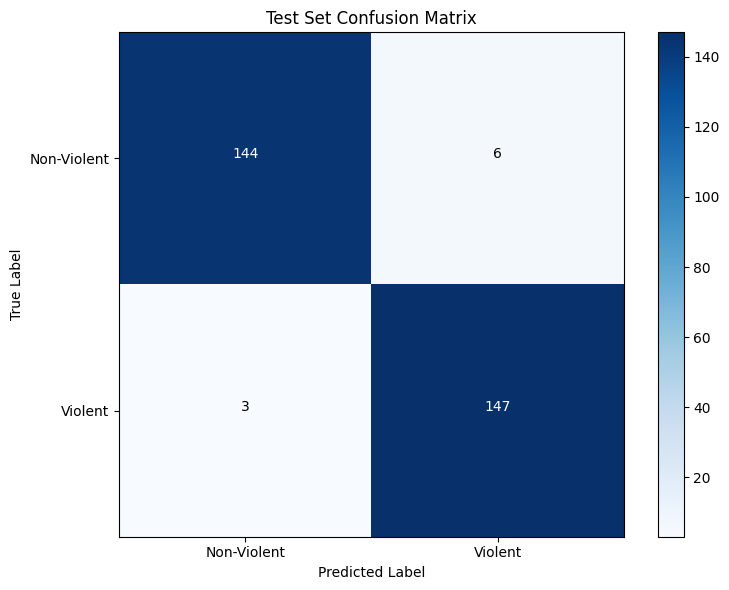

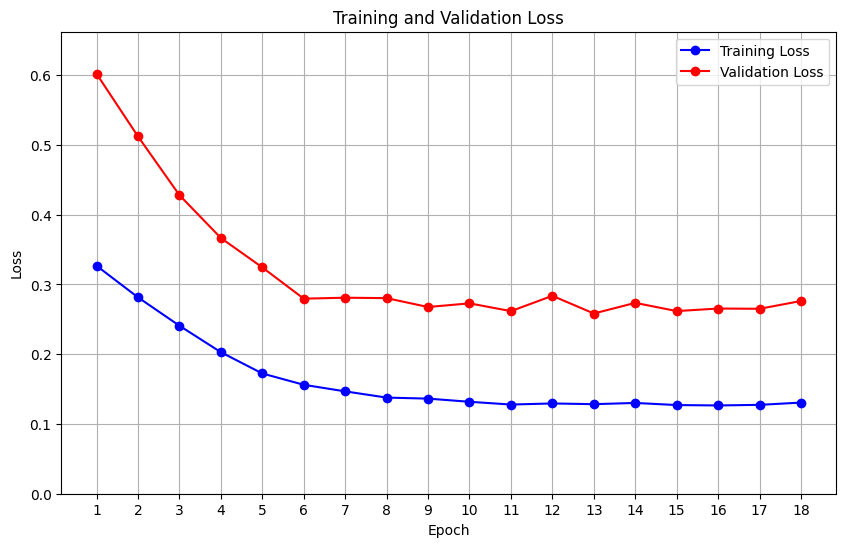

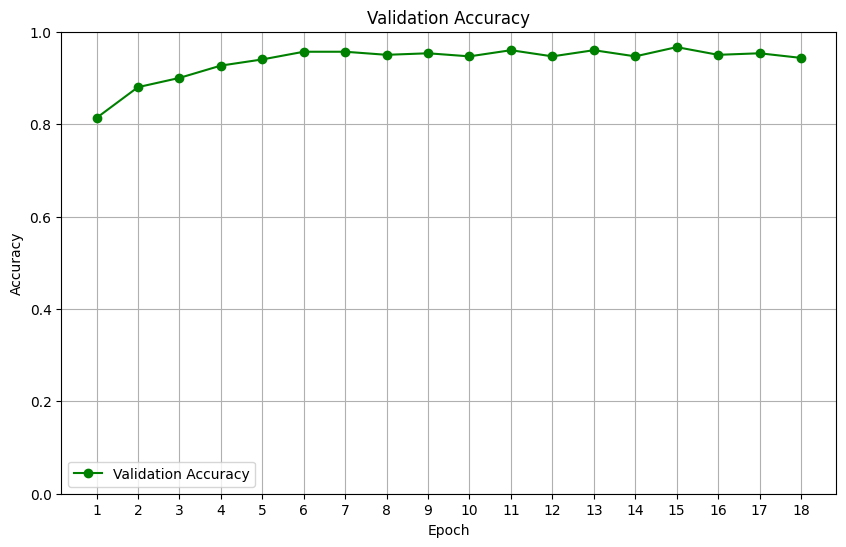

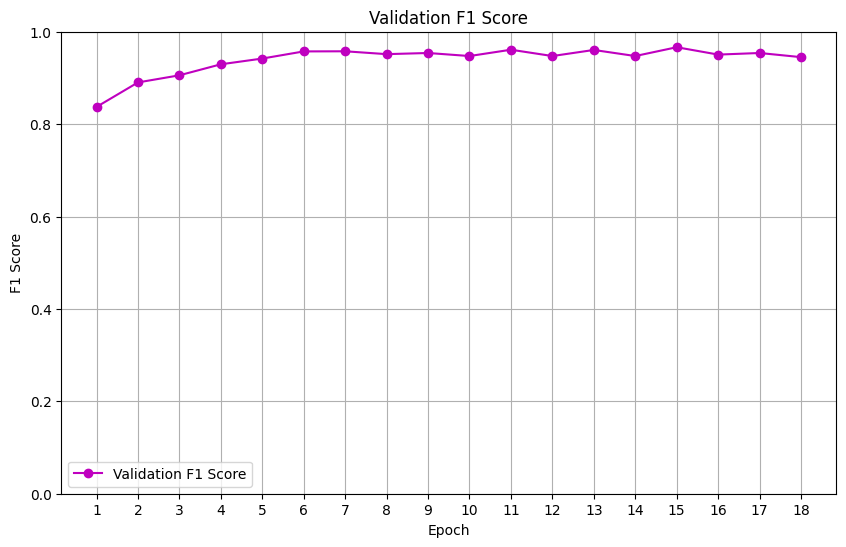

In [12]:
# ---- Testing Phase ----
print("\n" + "=" * 60)
print("FINAL MODEL EVALUATION ON TEST SET")
print("=" * 60)

# Load best model
model.load_state_dict(torch.load('/kaggle/working/best_mvit_model.pth'))
print("Loaded best model for testing...")

# Evaluate on test set
test_acc, test_prec, test_rec, test_f1, test_loss, test_preds, test_labels = evaluate(model, test_loader, "Test")

print(f"\nFINAL TEST RESULTS:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.4f}")
print(f"  Test Precision: {test_prec:.4f}")
print(f"  Test Recall: {test_rec:.4f}")
print(f"  Test F1-Score: {test_f1:.4f}")

# Detailed classification report
print(f"\nDETAILED CLASSIFICATION REPORT:")
print(classification_report(test_labels, test_preds, target_names=['Non-Violent', 'Violent']))

# Plot confusion matrix
plot_confusion_matrix(test_labels, test_preds, "Test Set Confusion Matrix")

num_epochs = len(train_losses)
epochs = range(1, num_epochs + 1)

# ------------------------- LOSS PLOT -------------------------
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, 'b-o', label='Training Loss')
plt.plot(epochs, val_losses, 'r-o', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0, max(max(train_losses), max(val_losses)) * 1.1)
plt.xticks(epochs)
plt.legend(loc="best")
plt.grid(True)
plt.show()

# ------------------------- ACCURACY PLOT -------------------------
plt.figure(figsize=(10, 6))
plt.plot(epochs, val_accuracies, 'g-o', label='Validation Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(epochs)
plt.legend(loc="best")
plt.grid(True)
plt.show()

# ------------------------- F1 PLOT -------------------------
plt.figure(figsize=(10, 6))
plt.plot(epochs, val_f1_scores, 'm-o', label='Validation F1 Score')
plt.title('Validation F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.xticks(epochs)
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [19]:
import torch
import torch.nn as nn
import cv2
import os
import numpy as np
from torchvision import transforms
from torchvision.models.video import mvit_v2_s, MViT_V2_S_Weights
import json
from pathlib import Path
import argparse
from tqdm import tqdm

class VideoProcessor:
    def __init__(self, model_path, frames_per_clip=16, device='cuda'):
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')
        self.frames_per_clip = frames_per_clip
        
        # Define the same transform used in training
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.45, 0.45, 0.45], std=[0.225, 0.225, 0.225])
        ])
        
        # Load the model
        self.model = self.load_model(model_path)
        self.model.eval()
        
    def load_model(self, model_path):
        """Load the trained MViT model"""
        # Initialize the model with the same architecture as training
        model = mvit_v2_s(weights=MViT_V2_S_Weights.DEFAULT)
        model.head[1] = nn.Linear(model.head[1].in_features, 2)  # Binary classification
        
        # Load the trained weights
        model.load_state_dict(torch.load(model_path, map_location=self.device))
        model = model.to(self.device)
        
        return model
    
    def extract_frames(self, video_path):
        """Extract frames from video similar to training"""
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise ValueError(f"Could not open video: {video_path}")
            
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames == 0:
            raise ValueError(f"No frames found in video: {video_path}")
            
        # Sample frames uniformly
        idxs = torch.linspace(0, total_frames - 1, steps=self.frames_per_clip).long()
        
        frames = []
        frame_count = 0
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
                
            if frame_count in idxs:
                # Convert BGR to RGB
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                # Convert to PIL Image format
                frame = transforms.functional.to_pil_image(frame)
                frames.append(frame)
                
            frame_count += 1
            
        cap.release()
        
        if len(frames) != self.frames_per_clip:
            raise ValueError(f"Expected {self.frames_per_clip} frames, got {len(frames)}")
            
        return frames
    
    def preprocess_frames(self, frames):
        """Apply transformations and prepare for model input"""
        # Apply transforms to each frame
        transformed_frames = [self.transform(frame) for frame in frames]
        
        # Stack frames: (T, C, H, W)
        video_tensor = torch.stack(transformed_frames)
        
        # Permute to (C, T, H, W) for MViT
        video_tensor = video_tensor.permute(1, 0, 2, 3)
        
        # Add batch dimension: (1, C, T, H, W)
        video_tensor = video_tensor.unsqueeze(0)
        
        return video_tensor.to(self.device)
    
    def predict_single_video(self, video_path):
        """Predict violence classification for a single video"""
        try:
            # Extract and preprocess frames
            frames = self.extract_frames(video_path)
            video_tensor = self.preprocess_frames(frames)
            
            # Make prediction
            with torch.no_grad():
                outputs = self.model(video_tensor)
                probabilities = torch.softmax(outputs, dim=1)
                predicted_class = torch.argmax(probabilities, dim=1).item()
                confidence = probabilities[0][predicted_class].item()
            
            result = {
                'video_path': str(video_path),
                'prediction': 'violent' if predicted_class == 1 else 'non-violent',
                'confidence': confidence,
                'raw_probabilities': {
                    'non-violent': probabilities[0][0].item(),
                    'violent': probabilities[0][1].item()
                }
            }
            
            return result
            
        except Exception as e:
            return {
                'video_path': str(video_path),
                'error': str(e),
                'prediction': None,
                'confidence': None
            }
    
    def test_videos(self, video_paths, output_file=None):
        """Test multiple videos and return results"""
        results = []
        
        print(f"Testing {len(video_paths)} videos...")
        
        for video_path in tqdm(video_paths, desc="Processing videos"):
            result = self.predict_single_video(video_path)
            results.append(result)
            
            # Print result
            if result.get('error'):
                print(f"❌ {Path(video_path).name}: ERROR - {result['error']}")
            else:
                pred = result['prediction']
                conf = result['confidence']
                emoji = "🔴" if pred == 'violent' else "🟢"
                print(f"{emoji} {Path(video_path).name}: {pred.upper()} ({conf:.3f})")
        
        # Save results if output file specified
        if output_file:
            with open(output_file, 'w') as f:
                json.dump(results, f, indent=2)
            print(f"\nResults saved to: {output_file}")
        
        return results

def get_video_files(directory, extensions=None):
    """Get all video files from a directory"""
    if extensions is None:
        extensions = ['.mp4', '.avi', '.mov', '.mkv', '.wmv', '.flv', '.webm']
    
    video_files = []
    directory = Path(directory)
    
    for ext in extensions:
        video_files.extend(directory.glob(f"*{ext}"))
        video_files.extend(directory.glob(f"*{ext.upper()}"))
    
    return sorted(video_files)


processor = VideoProcessor('/kaggle/input/mvitv2/pytorch/v2/1/best_mvit_model.pth')
result1 = processor.predict_single_video('/kaggle/input/violence-video/V_103.mp4')
result2 = processor.predict_single_video('/kaggle/input/valdata/val/Basketball/v_Basketball_g10_c03.avi')
print(result1)
print(result2)

{'video_path': '/kaggle/input/violence-video/V_103.mp4', 'prediction': 'violent', 'confidence': 0.9987898468971252, 'raw_probabilities': {'non-violent': 0.0012101174797862768, 'violent': 0.9987898468971252}}
{'video_path': '/kaggle/input/valdata/val/Basketball/v_Basketball_g10_c03.avi', 'prediction': 'non-violent', 'confidence': 0.9258944988250732, 'raw_probabilities': {'non-violent': 0.9258944988250732, 'violent': 0.07410553842782974}}
